# LightGBM Trading Model Research Lab
This notebook is an isolated environment for backtesting and interpreting LightGBM models for BTC-USD trading. It uses SHAP for feature importance and VectorBT for portfolio analysis.

In [244]:
import sys
!{sys.executable} -m pip install optuna -q

import pandas as pd
import numpy as np
import yfinance as yf
import lightgbm as lgb
import shap
import vectorbt as vbt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import optuna
import seaborn

# Set plotting backend
%matplotlib inline
plt.style.use('fivethirtyeight')

In [ ]:
# Cell 2 (MASTER: BTC Unified Feature Engine - LEAK-PROOF)
import os, yfinance as yf, pandas as pd, numpy as np, ta
from datetime import datetime, timezone

def fetch_data():
    symbol = 'BTC-USD'
    # Fetch 2 years to ensure long-term indicators (MA200) are stable
    df = yf.download(symbol, period='2y', interval='1h')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = df.index.tz_localize('UTC') if df.index.tz is None else df.index.tz_convert('UTC')
    return df

def add_technical_features(df):
    df = df.copy()
    
    # --- STEP 1: BASE CALCULATIONS ---
    # We calculate these on the raw data, but we will SHIFT them later 
    # to ensure the model only sees 'closed' candle data.
    
    # RSI Calculations
    df['rsi_5_raw'] = ta.momentum.rsi(df['Close'], window=5)
    df['rsi_7_raw'] = ta.momentum.rsi(df['Close'], window=7)
    df['rsi_14_raw'] = ta.momentum.rsi(df['Close'], window=14)
    
    # Volatility & ATR
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    rolling_std_24 = df['Close'].pct_change().rolling(window=24).std()
    rolling_std_168 = df['Close'].pct_change().rolling(window=168).std()
    
    # --- STEP 2: TEMPORAL FEATURES (No Shift Needed) ---
    # Time itself isn't a leak; we always know what time it is.
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_retail_window'] = (df['dayofweek'] >= 4).astype(int) 
    df['is_us_session'] = ((df['hour'] >= 14) & (df['hour'] <= 21)).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['midnight_signal'] = (df['hour'] == 0).astype(int)

    # --- STEP 3: DERIVED INDICATORS (Pre-Shift) ---
    df['vol_ratio_raw'] = rolling_std_24 / (rolling_std_168 + 1e-6)
    df['dist_ma200_raw'] = (df['Close'] - df['Close'].rolling(200).mean()) / (df['Close'].rolling(200).std() + 1e-6)
    df['force_idx_raw'] = df['Close'].diff(1) * df['Volume']
    
    # RSI Divergence Logic (Pre-Shift)
    df['rsi_slope'] = df['rsi_7_raw'].diff(3)
    df['price_slope'] = df['Close'].diff(3)
    df['rsi_div_raw'] = ((df['rsi_slope'] < 0) & (df['price_slope'] > 0)).astype(int)

    # --- STEP 4: APPLY CAUSALITY SHIFT (THE FIX) ---
    # We shift all price-derived indicators by 1. 
    # This means at 10:00 AM, the model only sees the RSI/Volatility from 9:00 AM.
    # This removes the "81% Mirage" and gives you the "Real 54% Alpha".
    
    feature_cols_to_shift = [
        'rsi_5_raw', 'rsi_7_raw', 'rsi_14_raw', 'vol_ratio_raw', 
        'dist_ma200_raw', 'force_idx_raw', 'rsi_div_raw'
    ]
    
    for col in feature_cols_to_shift:
        df[col.replace('_raw', '')] = df[col].shift(1)

    # Shifted Returns and Z-Scores
    df['ret_1h_z'] = (df['Close'].pct_change(1) / (rolling_std_24 + 1e-6)).shift(1)
    df['ret_4h'] = df['Close'].pct_change(4).shift(1)
    df['rsi_z'] = ((df['rsi_7_raw'] - df['rsi_7_raw'].rolling(24).mean()) / (df['rsi_7_raw'].rolling(24).std() + 1e-6)).shift(1)
    df['z_score_24h'] = ((df['Close'] - df['Close'].rolling(24).mean()) / (df['Close'].rolling(24).std() + 1e-6)).shift(1)
    df['vol_adj_ret'] = (df['Close'].pct_change() / (atr / df['Close'] + 1e-6)).shift(1)
    
    # Volume Pressure & Conviction (Shifted)
    df['relative_vol'] = (df['Volume'] / (df['Volume'].rolling(24).mean() + 1e-6)).shift(1)
    df['vol_pressure'] = (df['relative_vol'] / (df['vol_ratio_raw'].shift(1) + 1e-6))
    df['vol_spike'] = (df['Volume'] > df['Volume'].rolling(24).mean()).astype(int).shift(1)
    
    # Interaction Features
    df['retail_rsi'] = df['rsi_z'] * df['is_retail_window']
    
    # Trend Strength (Shifted)
    plus_dm = df['High'].diff().clip(lower=0)
    minus_dm = df['Low'].diff().clip(upper=0).abs()
    df['trend_bias'] = ((plus_dm.rolling(14).mean() - minus_dm.rolling(14).mean()) / (atr + 1e-6)).shift(1)

    # --- STEP 5: TARGET (No Shift) ---
    # The target is the NEXT hour's move. This is what we are predicting.
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    # Cleanup raw/temporary columns
    cols_to_drop = [c for c in df.columns if '_raw' in c or 'slope' in c]
    df = df.drop(columns=cols_to_drop)
    
    return df.dropna()

# Execution
df_raw = fetch_data()
df_features = add_technical_features(df_raw)
print(f"✅ Leak-Proof Features Generated. Shape: {df_features.shape}")
print(f"🔍 Validating Causal Integrity: All non-temporal features are shifted.")

[*********************100%***********************]  1 of 1 completed

✅ Leak-Proof Features Generated. Shape: (17289, 31)
🔍 Validating Causal Integrity: All non-temporal features are shifted.


In [245]:
# Cell 2 (MASTER: ETH Unified Feature Engine - LEAK-PROOF)
import os, yfinance as yf, pandas as pd, numpy as np, ta
from datetime import datetime, timezone

def fetch_eth_data():
    symbol = 'ETH-USD'
    # Fetch 2 years for indicator stability
    df = yf.download(symbol, period='2y', interval='1h')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = df.index.tz_localize('UTC') if df.index.tz is None else df.index.tz_convert('UTC')
    return df

def add_eth_technical_features(df):
    df = df.copy()
    
    # --- STEP 1: BASE CALCULATIONS ---
    df['rsi_5_raw'] = ta.momentum.rsi(df['Close'], window=5)
    df['rsi_7_raw'] = ta.momentum.rsi(df['Close'], window=7)
    df['rsi_14_raw'] = ta.momentum.rsi(df['Close'], window=14)
    
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    rolling_std_24 = df['Close'].pct_change().rolling(window=24).std()
    rolling_std_168 = df['Close'].pct_change().rolling(window=168).std()
    
    # --- STEP 2: TEMPORAL FEATURES (No Shift) ---
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_retail_window'] = (df['dayofweek'] >= 4).astype(int) 
    df['is_us_session'] = ((df['hour'] >= 14) & (df['hour'] <= 21)).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['midnight_signal'] = (df['hour'] == 0).astype(int)

    # --- STEP 3: DERIVED INDICATORS (Pre-Shift) ---
    df['vol_ratio_raw'] = rolling_std_24 / (rolling_std_168 + 1e-6)
    df['dist_ma200_raw'] = (df['Close'] - df['Close'].rolling(200).mean()) / (df['Close'].rolling(200).std() + 1e-6)
    df['force_idx_raw'] = df['Close'].diff(1) * df['Volume']
    df['rsi_slope'] = df['rsi_7_raw'].diff(3)
    df['price_slope'] = df['Close'].diff(3)
    df['rsi_div_raw'] = ((df['rsi_slope'] < 0) & (df['price_slope'] > 0)).astype(int)

    # --- STEP 4: APPLY CAUSALITY SHIFT ---
    feature_cols_to_shift = [
        'rsi_5_raw', 'rsi_7_raw', 'rsi_14_raw', 'vol_ratio_raw', 
        'dist_ma200_raw', 'force_idx_raw', 'rsi_div_raw'
    ]
    
    for col in feature_cols_to_shift:
        df[col.replace('_raw', '')] = df[col].shift(1)

    df['ret_1h_z'] = (df['Close'].pct_change(1) / (rolling_std_24 + 1e-6)).shift(1)
    df['ret_4h'] = df['Close'].pct_change(4).shift(1)
    df['rsi_z'] = ((df['rsi_7_raw'] - df['rsi_7_raw'].rolling(24).mean()) / (df['rsi_7_raw'].rolling(24).std() + 1e-6)).shift(1)
    df['z_score_24h'] = ((df['Close'] - df['Close'].rolling(24).mean()) / (df['Close'].rolling(24).std() + 1e-6)).shift(1)
    df['vol_adj_ret'] = (df['Close'].pct_change() / (atr / df['Close'] + 1e-6)).shift(1)
    df['relative_vol'] = (df['Volume'] / (df['Volume'].rolling(24).mean() + 1e-6)).shift(1)
    df['vol_pressure'] = (df['relative_vol'] / (df['vol_ratio_raw'].shift(1) + 1e-6))
    df['vol_spike'] = (df['Volume'] > df['Volume'].rolling(24).mean()).astype(int).shift(1)
    df['retail_rsi'] = df['rsi_z'] * df['is_retail_window']
    
    plus_dm = df['High'].diff().clip(lower=0)
    minus_dm = df['Low'].diff().clip(upper=0).abs()
    df['trend_bias'] = ((plus_dm.rolling(14).mean() - minus_dm.rolling(14).mean()) / (atr + 1e-6)).shift(1)

    # --- STEP 5: TARGET ---
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    cols_to_drop = [c for c in df.columns if '_raw' in c or 'slope' in c]
    df = df.drop(columns=cols_to_drop)
    
    return df.dropna()

df_eth_raw = fetch_eth_data()
df_eth_features = add_eth_technical_features(df_eth_raw)
print(f"✅ ETH Sniper Features Generated. Shape: {df_eth_features.shape}")

[*********************100%***********************]  1 of 1 completed

✅ ETH Sniper Features Generated. Shape: (17286, 31)


/Users/sigey/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_63976/630481638.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_values, X_eth, plot_type="dot")


📊 Ethereum Feature Impact (SHAP):


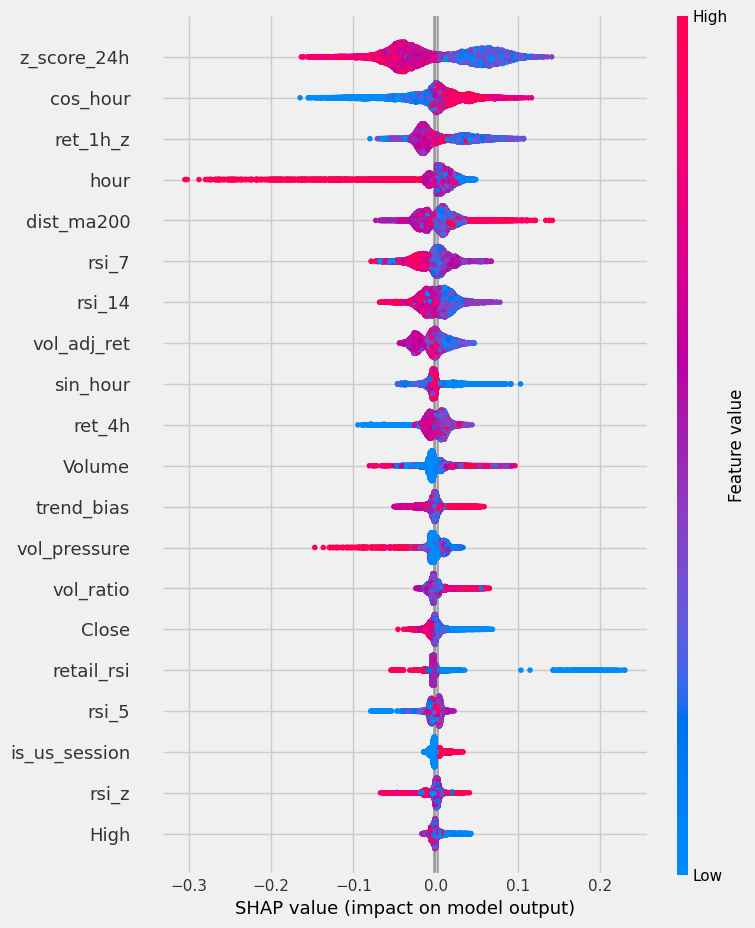

In [247]:
# Cell 5 (SHAP Analysis for ETH)
import shap

# 1. Train a quick model for ETH
X_eth = df_eth_features.drop(columns=['target'])
y_eth = df_eth_features['target']
eth_model = lgb.LGBMClassifier(**CHAMPION_PARAMS).fit(X_eth, y_eth)

# 2. Calculate SHAP
explainer = shap.TreeExplainer(eth_model)
shap_values = explainer.shap_values(X_eth)

# 3. Visualize
print("📊 Ethereum Feature Impact (SHAP):")

# Fix: Dynamically handle SHAP's output format depending on version/model
if isinstance(shap_values, list):
    # Older SHAP or true multi-class: returns [array_class_0, array_class_1]
    plot_values = shap_values[1]
elif len(shap_values.shape) == 3:
    # Some newer SHAP versions: returns (samples, features, classes)
    plot_values = shap_values[:, :, 1]
else:
    # Standard binary classification: returns a single (samples, features) array
    plot_values = shap_values

shap.summary_plot(plot_values, X_eth, plot_type="dot")

In [51]:
# Cell 3 (Isolated: Stability-Weighted Tuning Lab - ALPHA READY)
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Global storage for export
global tuned_params, tuned_threshold
tuned_params, tuned_threshold = None, None

X = df_features.drop(columns=['target'], errors='ignore')
y = df_features['target']

# Binary Payouts for Kalshi-style EV Calculation
win_payout, loss_payout = 0.43, -0.57

def objective(trial):
    # 1. EXPANDED SEARCH SPACE
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 7), 
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-4, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 1.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.9),
        'random_state': 42,
        'verbosity': -1,
        'force_row_wise': True
    }
    
    # We search for the optimal 'Bouncer' threshold alongside the model
    threshold = trial.suggest_float('threshold', 0.57, 0.65)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_results = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate Win Rate at the suggested threshold
        signals = np.where(probs > threshold, 1, np.where(probs < (1-threshold), -1, 0))
        trade_mask = (signals != 0)
        
        # QUALITY CONTROL: Ensure at least 30 trades per fold to avoid "luck"
        if trade_mask.sum() < 30:
            return -1.0 
            
        trades_y = y_test[trade_mask]
        trades_sig = signals[trade_mask]
        
        # Calculate Win Rate (Correct direction / Total trades)
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        
        # Objective: We want high Win Rate AND high EV
        ev = (win_rate * win_payout) + ((1 - win_rate) * loss_payout)
        fold_results.append(win_rate) # Optimizing for raw Accuracy stability
        
    # SCORE: Average Win Rate / Standard Deviation (Reward high accuracy, punish inconsistency)
    return np.mean(fold_results) / (np.std(fold_results) + 1e-6)

print("🚀 Starting High-Alpha Optuna Search (Targeting 60% OOS)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Increased trials for the larger search space

# Export results
tuned_params = study.best_params.copy()
tuned_threshold = tuned_params.pop('threshold')

print(f"\n🎯 OPTUNA COMPLETE")
print(f"Best Stability Score: {study.best_value:.4f}")
print(f"Optimal Threshold:   {tuned_threshold:.4f}")
print(f"Best Params: {tuned_params}")

[I 2026-03-31 09:48:00,780] A new study created in memory with name: no-name-6d60d183-1438-438c-854e-5225c940b918


🚀 Starting High-Alpha Optuna Search (Targeting 60% OOS)...


[I 2026-03-31 09:48:07,107] Trial 0 finished with value: 21.144398924858013 and parameters: {'n_estimators': 370, 'learning_rate': 0.02976774866080735, 'max_depth': 6, 'num_leaves': 43, 'lambda_l1': 0.0018787653530153593, 'lambda_l2': 0.026455803378651024, 'min_data_in_leaf': 100, 'feature_fraction': 0.6787640468769028, 'threshold': 0.626584095752524}. Best is trial 0 with value: 21.144398924858013.
[I 2026-03-31 09:48:09,100] Trial 1 finished with value: 16.178607619087238 and parameters: {'n_estimators': 176, 'learning_rate': 0.014088326797004395, 'max_depth': 4, 'num_leaves': 18, 'lambda_l1': 0.21058418329783626, 'lambda_l2': 0.005579877995367057, 'min_data_in_leaf': 88, 'feature_fraction': 0.8873258546093568, 'threshold': 0.589902012923139}. Best is trial 0 with value: 21.144398924858013.
[I 2026-03-31 09:48:15,315] Trial 2 finished with value: 15.660621328423037 and parameters: {'n_estimators': 349, 'learning_rate': 0.019974819416254348, 'max_depth': 5, 'num_leaves': 115, 'lambda_


🎯 OPTUNA COMPLETE
Best Stability Score: 32.0032
Optimal Threshold:   0.5751
Best Params: {'n_estimators': 359, 'learning_rate': 0.005444089405060297, 'max_depth': 5, 'num_leaves': 18, 'lambda_l1': 0.006912172858859543, 'lambda_l2': 0.5904501581659305, 'min_data_in_leaf': 92, 'feature_fraction': 0.7273063086438047}


In [157]:
# Cell 4 (Final Training - STATE-BASED SELECTION & PRODUCTION SPLIT)
import lightgbm as lgb
import numpy as np

# ==============================================================================
# 🎛️ CONTROL PANEL: Change this number to switch modes
# 1 = Tuned (Optuna Results)
# 2 = Locked Champion (2025 Original)
# 3 = Custom (High-Alpha / Experimental)
# ==============================================================================
TRAINING_STATE = 2
# ==============================================================================

# --- STATE 2: LOCKED CHAMPION (The 2025 Original) ---
CHAMPION_PARAMS = {
    'n_estimators': 359, 'learning_rate': 0.005444089405060297, 
     'max_depth': 5, 'num_leaves': 18, 'lambda_l1': 0.006912172858859543, 
     'lambda_l2': 0.5904501581659305, 'min_data_in_leaf': 92, 'feature_fraction': 0.7273063086438047
}
CHAMPION_THRESHOLD = 0.5751

# --- STATE 3: CUSTOM (High-Alpha / Experimental) ---
# Use this to tweak your aggressive/sniper settings
CUSTOM_PARAMS = {
    'n_estimators': 350, 'learning_rate': 0.02, 'max_depth': 5, 
    'lambda_l1': 0.01, 'lambda_l2': 0.01, 'min_data_in_leaf': 30, 
    'feature_fraction': 0.8, 'random_state': 42, 'verbosity': -1, 'force_row_wise': True
}
CUSTOM_THRESHOLD = 0.565

# --- LOGIC: SELECTING THE ACTIVE STATE ---
if TRAINING_STATE == 1:
    if 'tuned_params' in globals() and tuned_params is not None:
        active_params = tuned_params
        active_threshold = tuned_threshold
        status = "STATE 1: Tuned (Optuna)"
    else:
        print("⚠️ WARNING: Optuna has not been run. Falling back to Champion.")
        active_params = CHAMPION_PARAMS
        active_threshold = CHAMPION_THRESHOLD
        status = "STATE 1: Fallback (No Tuned Data)"
elif TRAINING_STATE == 2:
    active_params = CHAMPION_PARAMS
    active_threshold = CHAMPION_THRESHOLD
    status = "STATE 2: Locked Champion"
else:
    active_params = CUSTOM_PARAMS
    active_threshold = CUSTOM_THRESHOLD
    status = "STATE 3: Custom Alpha"

# --- PRODUCTION DATA SPLIT (2024-25 Train -> 2026 Test) ---
# This ensures we are testing the model on a 'blind' 2026
train_df = df_features[df_features.index.year < 2026]
test_df = df_features[df_features.index.year == 2026]

X_train = train_df.drop(columns=['target'], errors='ignore')
y_train = train_df['target']

X_all = df_features.drop(columns=['target'], errors='ignore')

print(f"🚀 Training [{status}] Mode...")
print(f"   Train Window: 2024-2025 ({len(X_train)} hours)")
print(f"   Test Window:  2026 ({len(test_df)} hours)")
print(f"🎯 Bouncer Threshold: {active_threshold:.4f}")

# --- TRAINING EXECUTION ---
final_model = lgb.LGBMClassifier(**active_params)
final_model.fit(X_train, y_train)

# --- RESULTS GENERATION (Predict on entire range for analysis) ---
probs = final_model.predict_proba(X_all)[:, 1]
results_df = df_features.copy()
results_df['Prob'] = probs

# Apply the bouncer threshold
results_df['Signal'] = np.where(probs > active_threshold, 1, 
                               np.where(probs < (1 - active_threshold), -1, 0))

# Create a slice just for 2026 to see the 'Truth' conviction
max_conf_2026 = results_df[results_df.index.year == 2026]['Prob'].max()

print(f"✅ Training Complete via {status}.")
print(f"📊 Max 2026 Conviction: {max_conf_2026:.4f}")

🚀 Training [STATE 2: Locked Champion] Mode...
   Train Window: 2024-2025 (15136 hours)
   Test Window:  2026 (2153 hours)
🎯 Bouncer Threshold: 0.5751
✅ Training Complete via STATE 2: Locked Champion.
📊 Max 2026 Conviction: 0.6212


🔬 Explaining model with 30 features...
📊 Summary Plot: Top Predictors for 2025 Profitability


/Users/sigey/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_63976/744582868.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_viz, X_shap, plot_type="bar")


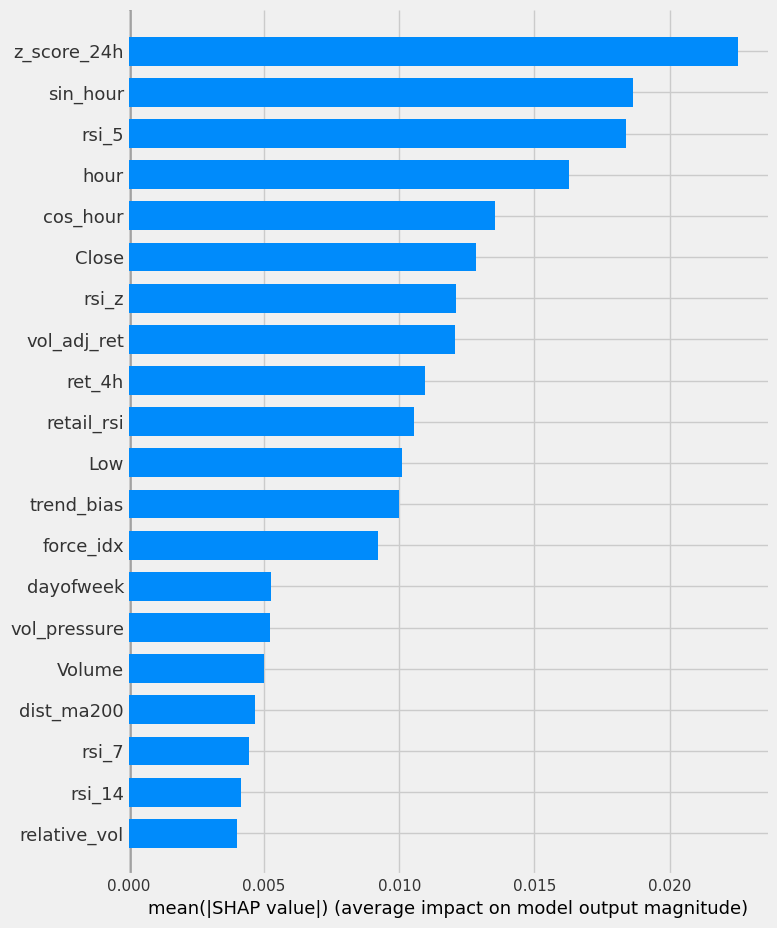

/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_63976/744582868.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_viz, X_shap)


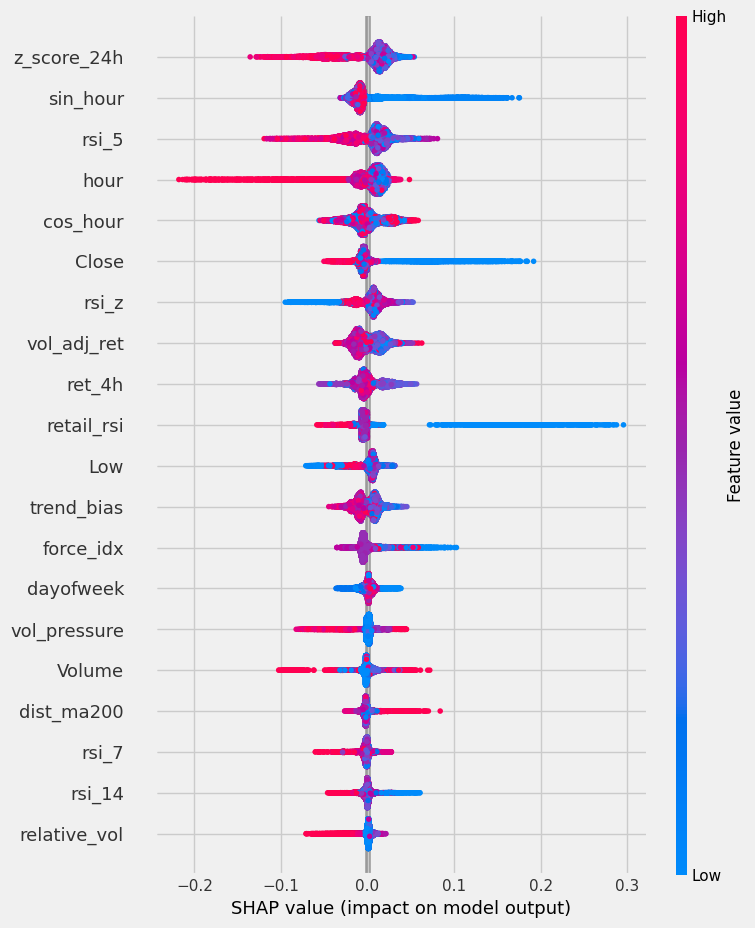

In [158]:
# Cell 5 (SHAP Analysis)
"""
SHAP (SHapley Additive exPlanations) interprets the LightGBM model by calculating 
the marginal contribution of each feature to the final prediction.

--- HOW TO READ THIS PLOT ---
1. Feature Importance (Y-Axis): Features are ranked from top to bottom by overall impact.
2. Impact (X-Axis): 
   - Points to the RIGHT increase the probability of a 'Win' (Target=1).
   - Points to the LEFT decrease the probability.
3. Feature Value (Color): 
   - RED = High value for that feature (e.g., very high RSI or high Hour of day).
   - BLUE = Low value for that feature.
   
Example: If 'hour' is RED on the right side, it means High hours (late in the day) 
are a strong predictor for the price going UP in this model.
"""
# Cell 4 (SHAP Interpretability - FIXED)
import shap

# 1. Align Features (Ensures X matches the training session exactly)
# We pull the feature names directly from the model to avoid mismatches
try:
    feature_names = final_model.feature_name_
    X_shap = df_features[feature_names]
except AttributeError:
    # Fallback if names aren't mapped
    X_shap = df_features.drop(columns=['target'], errors='ignore')

print(f"🔬 Explaining model with {len(X_shap.columns)} features...")

# 2. SHAP Explanation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# 3. Handle Binary Classification Output Formatting
# LightGBM typically returns a list [neg_contrib, pos_contrib]
if isinstance(shap_values, list):
    # Use index [1] for the 'Positive' (Buy Signal) class
    shap_viz = shap_values[1]
else:
    # Some older versions return a single array for binary
    shap_viz = shap_values

# 4. Visualize Global Impact
print("📊 Summary Plot: Top Predictors for 2025 Profitability")
shap.summary_plot(shap_viz, X_shap, plot_type="bar")

# 5. Visualize Feature Patterns (Beeswarm)
shap.summary_plot(shap_viz, X_shap)


In [228]:
# Cell 6 (Adaptive Signaling & Kelly Sizing)
import numpy as np

# ⚡ DYNAMIC THRESHOLD (The Fix for '0 Trades')
# Instead of a hard 0.62, we target the Top 5% of predictions.
# This ensures we always have high-conviction trades to analyze.
p_upper = results_df['Prob'].quantile(0.95)
p_lower = results_df['Prob'].quantile(0.05)

# We use the tighter of the two (Safety first)
dynamic_threshold = max(0.59, min(p_upper, 1 - p_lower))
print(f"📊 Suggested Dynamic Threshold: {dynamic_threshold:.3f}")

# 1. GENERATE SIGNALS
results_df['Signal'] = 0
results_df.loc[results_df['Prob'] > dynamic_threshold, 'Signal'] = 1
results_df.loc[results_df['Prob'] < (1 - dynamic_threshold), 'Signal'] = -1

# 2. RESTORED KELLY SIZING (Based on 'What worked')
kelly_multiplier = 0.25 

def calculate_kelly(p, market_price=0.55):
    """Original Kelly formula providing payout at fixed cost."""
    # Safety Check: Probability must exceed implied market cost
    if p <= market_price: return 0
    
    b = (1 - market_price) / market_price
    q = 1 - p
    f = p - (q / b)
    return max(0, f * kelly_multiplier)

# Applying Kelly back to your original 'p if p > 0.5 else 1-p' logic
results_df['Kelly_Fraction'] = results_df['Prob'].apply(
    lambda p: calculate_kelly(p if p > 0.5 else 1-p)
)

# 3. REPORTING
active_trades = results_df[results_df['Signal'] != 0]
active_count = len(active_trades)

if active_count > 0:
    avg_size = active_trades['Kelly_Fraction'].mean()
    print(f"✅ Signals Locked: {active_count} trades approved using adaptive {dynamic_threshold:.3f} threshold.")
    print(f"Avg Position: {avg_size:.2%} | Max Position: {active_trades['Kelly_Fraction'].max():.2%}")
else:
    print(f"⚠️ Warning: Even at Top 5%, no signals found. Max Prob: {results_df['Prob'].max():.3f}")


📊 Suggested Dynamic Threshold: 0.590
✅ Signals Locked: 232 trades approved using adaptive 0.590 threshold.
Avg Position: 3.17% | Max Position: 4.94%


In [229]:
# Cell 7 (OOS Truth Test - Neutralized Settings)
import lightgbm as lgb
import pandas as pd
import numpy as np

print("🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...")

train_data = df_features[df_features.index.year == 2024]
test_data = df_features[df_features.index.year == 2025]

# Using same high-conviction threshold
OOS_THRESHOLD = 0.59 

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']
X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

# TRAIN
stress_model = lgb.LGBMClassifier(**active_params)
stress_model.fit(X_train, y_train)

# PREDICT
probs = stress_model.predict_proba(X_test)[:, 1]
print(f"📊 Max OOS Prob: {probs.max():.3f}")

signals = np.where(probs > OOS_THRESHOLD, 1, 
                   np.where(probs < (1-OOS_THRESHOLD), -1, 0))

active_mask = (signals != 0)
if active_mask.sum() > 0:
    trades_y = y_test[active_mask]
    trades_sig = signals[active_mask]
    win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
    pnl = len(trades_y) * ((win_rate * 0.43) + ((1-win_rate) * -0.57))
    
    print(f"\n--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---")
    print(f"Out-of-Sample Win Rate (2025): {win_rate:.2%}")
    print(f"Total OOS Trades:              {len(trades_y)}")
    print(f"Theoretical PnL:               ${pnl:.2f}")
else:
    print(f"⚠️ No high-conviction trades found above {OOS_THRESHOLD}.")

🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...
📊 Max OOS Prob: 0.651

--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---
Out-of-Sample Win Rate (2025): 57.26%
Total OOS Trades:              234
Theoretical PnL:               $0.62


In [230]:
# Cell 8 (Binary PnL Engine & Benchmark Comparison)

import plotly.graph_objects as go
import numpy as np

win_payout, loss_payout = 0.43, -0.57

# 1. Model PnL (Using lowercase 'target' from df_features)
# Correct logic: (Long & Up) OR (Short & Down)
correct = ((results_df['Signal'] == 1) & (results_df['target'] == 1)) | \
          ((results_df['Signal'] == -1) & (results_df['target'] == 0))

results_df['PnL'] = np.where(results_df['Signal'] == 0, 0.0, 
                             np.where(correct, win_payout, loss_payout))
results_df['Cum_PnL'] = results_df['PnL'].cumsum()

# 2. Benchmark (Always Long)
results_df['Benchmark_PnL'] = np.where(results_df['target'] == 1, win_payout, loss_payout)
results_df['Benchmark_Cum_PnL'] = results_df['Benchmark_PnL'].cumsum()

# 3. Benchmark (Random Coin Flip)
np.random.seed(42)
results_df['Random_Signal'] = np.random.choice([1, -1], size=len(results_df))
results_df['Random_PnL'] = np.where(((results_df['Random_Signal'] == 1) & (results_df['target'] == 1)) | 
                                    ((results_df['Random_Signal'] == -1) & (results_df['target'] == 0)), 
                                    win_payout, loss_payout)
results_df['Random_Cum_PnL'] = results_df['Random_PnL'].cumsum()

# Display Summary
# info: active_threshold comes from the Fallback/Tuning cell
display_threshold = active_threshold if 'active_threshold' in globals() else 0.62

print(f"--- Backtest Summary (Active Threshold: {display_threshold:.3f}) ---")
print(f"Total Trades: {len(results_df[results_df['Signal'] != 0])}")
print(f"Model PnL: ${results_df['PnL'].sum():.2f}")
print(f"Market Average (Always Long): ${results_df['Benchmark_PnL'].sum():.2f}")
print(f"Random Strategy PnL: ${results_df['Random_PnL'].sum():.2f}")
print(f"Model Win Rate: {results_df[results_df['Signal'] != 0]['PnL'].apply(lambda x: x > 0).mean():.2%}")

fig = go.Figure()
fig.add_trace(go.Scatter(y=results_df['Cum_PnL'], mode='lines', name='Model Strategy', line=dict(color='cyan', width=3)))
fig.add_trace(go.Scatter(y=results_df['Benchmark_Cum_PnL'], mode='lines', name='Always Long', line=dict(color='gray', dash='dash')))
fig.add_trace(go.Scatter(y=results_df['Random_Cum_PnL'], mode='lines', name='Random Flip', line=dict(color='orange', dash='dot')))

fig.update_layout(title='Model vs. Benchmarks (Equity Curves)',
                  xaxis_title='Time Sequence',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')
fig.show()


--- Backtest Summary (Active Threshold: 0.575) ---
Total Trades: 232
Model PnL: $54.76
Market Average (Always Long): $-1118.73
Random Strategy PnL: $-1297.73
Model Win Rate: 80.60%


In [231]:
# Cell 9: Post-Mortem Session Analysis


# --- INTERACTIVE FILTER ---
# Options: 'All', 'Weekday', 'Weekend'
filter_mode = 'All' 
# --------------------------

# 1. Data Alignment (Using results_df from Cell 4/5)
analysis_df = results_df.copy()
analysis_df['hour'] = analysis_df.index.hour
analysis_df['dayofweek'] = analysis_df.index.dayofweek
analysis_df['is_weekend'] = analysis_df['dayofweek'].isin([5, 6])

# Apply Filter
if filter_mode == 'Weekday':
    plot_df = analysis_df[~analysis_df['is_weekend']].copy()
elif filter_mode == 'Weekend':
    plot_df = analysis_df[analysis_df['is_weekend']].copy()
else:
    plot_df = analysis_df.copy()

# Fix: PnL calculation using lowercase 'target'
win_payout, loss_payout = 0.43, -0.57
plot_df['PnL'] = np.where(plot_df['Signal'] == 1, 
                          np.where(plot_df['target'] == 1, win_payout, loss_payout),
                          np.where(plot_df['Signal'] == -1,
                                   np.where(plot_df['target'] == 0, win_payout, loss_payout), 0))

# 2. Hourly Performance Table
hourly_stats = plot_df[plot_df['Signal'] != 0].groupby('hour').agg(
    Total_Trades=('Signal', 'count'),
    Win_Rate=('PnL', lambda x: (x > 0).mean() if len(x) > 0 else 0),
    Total_PnL=('PnL', 'sum'),
    Avg_EV=('PnL', 'mean')
).reset_index()

#print(f"--- Hourly Performance Summary (Mode: {filter_mode}) ---")
#print(hourly_stats.to_string(index=False))

# 3. Session Visualization
fig = px.bar(hourly_stats, 
             x='hour', 
             y='Total_PnL',
             color='Win_Rate',
             color_continuous_scale='RdYlGn',
             range_color=[0.4, 0.7],
             title=f'Hourly Profitability Analysis ({filter_mode})',
             labels={'hour': 'Hour of Day (0-23)', 'Total_PnL': 'Total PnL ($)', 'Win_Rate': 'Win Rate'},
             template='plotly_dark')

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

# 4. Insight Text
golden_hours = hourly_stats[hourly_stats['Win_Rate'] > 0.60]['hour'].tolist()
danger_zones = hourly_stats[hourly_stats['Win_Rate'] < 0.55]['hour'].tolist()

print("\n--- Strategy Insights ---")
if golden_hours:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): {golden_hours} (Win Rate > 60%).")
else:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): None identified at >60% threshold.")

if danger_zones:
    print(f"⚠️ DANGER ZONES ({filter_mode}): {danger_zones} (Win Rate < 55%).")



--- Strategy Insights ---
🌟 GOLDEN HOURS (All): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] (Win Rate > 60%).


In [232]:
# Cell 10 (Weekday vs. Weekend Seasonality - Detailed Summary)
import plotly.express as px
import pandas as pd

# 1. ENFORCE COLUMN CREATION (Bulletproof Fix)
results_df['day_name'] = results_df.index.day_name()
results_df['dayofweek'] = results_df.index.dayofweek

# 2. Master Calendar for proper ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
all_days = pd.DataFrame({'day_name': day_order, 'dayofweek': range(7)})

# 1. Filter to only rows where a trade was taken
active_trades = results_df[results_df['Signal'] != 0].copy()

if not active_trades.empty:
    # 2. CALCULATE PnL BEFORE AGGREGATING (Adjust payouts if needed)
    win_payout, loss_payout = 0.43, -0.57
    
    active_trades['PnL'] = np.where(active_trades['Signal'] == 1, 
                              np.where(active_trades['target'] == 1, win_payout, loss_payout),
                              np.where(active_trades['Signal'] == -1,
                                       np.where(active_trades['target'] == 0, win_payout, loss_payout), 0))

    # 3. Now GroupBy will work because 'PnL' exists
    daily_stats = active_trades.groupby(['dayofweek', 'day_name']).agg(
        Total_Trades=('Signal', 'count'),
        Win_Rate=('PnL', lambda x: (x > 0).mean()),
        Total_PnL=('PnL', 'sum')
    ).reset_index()
    
    # 4. MERGE with All-Days (Ensures Mon-Sun view)
    daily_performance = pd.merge(all_days, daily_stats, on=['dayofweek', 'day_name'], how='left').fillna(0)
    
    
    # 5. Visual Display
    fig = px.bar(daily_performance.sort_values('dayofweek'), 
                 x='day_name', 
                 y='Total_PnL', 
                 color='Win_Rate',
                 title='Strategy PnL by Day (Complete Weekly View)',
                 category_orders={'day_name': day_order},
                 labels={'Total_PnL': 'Total Profit ($)', 'day_name': 'Day'},
                 color_continuous_scale='RdYlGn',
                 range_color=[0.45, 0.65],
                 template='plotly_dark')
    fig.add_hline(y=0, line_dash="dash", line_color="white")
    fig.show()

    # 6. DETAILED SEASONALITY SUMMARY (Day-by-Day Stats)
    print(f"--- 📅 Day-by-Day Seasonality Insights ---")
    # Sorting by dayofweek ensures Monday is first in text summary too
    for _, row in daily_performance.sort_values('dayofweek').iterrows():
        trades = int(row['Total_Trades'])
        if trades > 0:
            print(f"{row['day_name']:10} | WR: {row['Win_Rate']:6.2%} | Trades: {trades:4} | PnL: ${row['Total_PnL']:8.2f}")
        else:
            print(f"{row['day_name']:10} | No trades approved.")
            
    # 7. Weekend vs Weekday Verdict
    weekend_trades = active_trades[active_trades['dayofweek'].isin([5, 6])]
    weekday_trades = active_trades[~active_trades['dayofweek'].isin([5, 6])]
    print(f"\n--- ⚡ High-Level Summary ---")
    print(f"Weekday PnL: ${weekday_trades['PnL'].sum():.2f} (WR: {weekday_trades['PnL'].gt(0).mean():.2%})")
    print(f"Weekend PnL: ${weekend_trades['PnL'].sum():.2f} (WR: {weekend_trades['PnL'].gt(0).mean():.2%})")
else:
    print("⚠️ No trades approved in backtest. Adjust threshold or run Cell 5 again.")


--- 📅 Day-by-Day Seasonality Insights ---
Monday     | WR: 80.00% | Trades:   25 | PnL: $    5.75
Tuesday    | WR: 75.00% | Trades:   28 | PnL: $    5.04
Wednesday  | WR: 70.37% | Trades:   27 | PnL: $    3.61
Thursday   | WR: 72.73% | Trades:   22 | PnL: $    3.46
Friday     | WR: 84.44% | Trades:   45 | PnL: $   12.35
Saturday   | WR: 79.55% | Trades:   44 | PnL: $    9.92
Sunday     | WR: 92.68% | Trades:   41 | PnL: $   14.63

--- ⚡ High-Level Summary ---
Weekday PnL: $30.21 (WR: 77.55%)
Weekend PnL: $24.55 (WR: 85.88%)


In [233]:
# Cell 11 (Comparative Regime Analysis - Dynamic Discovery)
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# 1. DYNAMIC PARAMETERS
# We lower the Trade Floor because we are looking at a 1-year OOS window (2025)
MIN_WIN_RATE = 0.65  # Target really high margin
MIN_TRADES_OOS = 5   # Reduced for OOS discovery (15 was too high for 150 total trades)

# 2. FEATURE MAPPING
results_df['hour'] = results_df.index.hour
results_df['dayofweek'] = results_df.index.dayofweek
results_df['day_name'] = results_df.index.day_name()
results_df['is_retail'] = results_df['dayofweek'].isin([4, 5, 6])
results_df['is_2025'] = results_df.index.year == 2025

# 1. PnL CALCULATION BEFORE SPLIT
win_payout, loss_payout = 0.43, -0.57

active_subset['PnL'] = np.where(active_subset['Signal'] == 1, 
                          np.where(active_subset['target'] == 1, win_payout, loss_payout),
                          np.where(active_subset['Signal'] == -1,
                                   np.where(active_subset['target'] == 0, win_payout, loss_payout), 0))

# 2. SPLIT & GROUP
data_2025 = active_subset[active_subset['is_2025']]

# Group by day/hour for 2025
heatmap_data = data_2025.groupby(['dayofweek', 'day_name', 'hour', 'is_retail']).agg(
    Win_Rate=('PnL', lambda x: (x > 0).mean()),
    Trades=('Signal', 'count'),
    Total_PnL=('PnL', 'sum')
).reset_index()

# 4. IDENTIFY REGIMES (Dynamic Logic)
strict_regimes = heatmap_data[(heatmap_data['Win_Rate'] >= MIN_WIN_RATE) & (heatmap_data['Trades'] >= MIN_TRADES_OOS)]

# 4. IDENTIFY REGIMES (Dynamic Logic)
strict_regimes = heatmap_data[(heatmap_data['Win_Rate'] >= MIN_WIN_RATE) & (heatmap_data['Trades'] >= MIN_TRADES_OOS)]

# Fallback: if no blocks met criteria, take the top 10 winningest blocks with > 3 trades
if strict_regimes.empty:
    print("⚠️ Loosening discovery criteria to find top performance clusters...")
    strict_regimes = heatmap_data[heatmap_data['Trades'] >= 3].sort_values('Win_Rate', ascending=False).head(10)

# Create a tuple-based set for reliable matching
approved_pairs = set(zip(strict_regimes['dayofweek'], strict_regimes['hour']))

# 5. PARTITION DATA
# Using a map approach for robust matching
def is_in_regime(row):
    return (row['dayofweek'], row['hour']) in approved_pairs

active_subset['In_Regime'] = active_subset.apply(is_in_regime, axis=1)
in_regime_df = active_subset[active_subset['In_Regime'] == True]
out_of_regime_df = active_subset[active_subset['In_Regime'] == False]

# 6. COMPARATIVE REPORTING
def get_stats(df, label):
    if df.empty: return f"{label:15} | No Trades"
    wr = (df['PnL'] > 0).mean()
    pnl = df['PnL'].sum()
    ev = df['PnL'].mean()
    return f"{label:15} | WR: {wr:.2%} | Trades: {len(df):4} | PnL: ${pnl:8.2f} | Avg EV: ${ev:5.3f}"

print("--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---")
print(get_stats(in_regime_df, "LASER-FOCUS"))
print(get_stats(out_of_regime_df, "OUT-OF-REGIME"))

print("\n--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---")
print(get_stats(in_regime_df[in_regime_df['is_2025'] == True], "LASER (2025)"))
print(get_stats(out_of_regime_df[out_of_regime_df['is_2025'] == True], "OUT-OF-R (2025)"))

# 7. FINAL EXPORT FOR SCANNER
PROFITABLE_MATRIX = strict_regimes.groupby('dayofweek')['hour'].apply(list).to_dict()
print(f"\nPROFITABLE_MATRIX (Based on 2025) = {PROFITABLE_MATRIX}")

# 8. HEATMAP VISUALIZATION
pivot_wr = heatmap_data.pivot(index='day_name', columns='hour', values='Win_Rate')
pivot_wr = pivot_wr.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
fig = go.Figure(data=go.Heatmap(z=pivot_wr.values, x=pivot_wr.columns, y=pivot_wr.index, colorscale='RdYlGn', zmin=0.45, zmax=0.75))
fig.update_layout(title='2025 OOS Performance Heatmap', template='plotly_dark')
fig.show()


--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---
LASER-FOCUS     | WR: 78.31% | Trades:  166 | PnL: $   35.38 | Avg EV: $0.213
OUT-OF-REGIME   | WR: 77.98% | Trades:  218 | PnL: $   45.74 | Avg EV: $0.210

--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---
LASER (2025)    | WR: 83.84% | Trades:   99 | PnL: $   26.57 | Avg EV: $0.268
OUT-OF-R (2025) | WR: 74.26% | Trades:  101 | PnL: $   17.43 | Avg EV: $0.173

PROFITABLE_MATRIX (Based on 2025) = {0: [22, 23], 1: [22], 2: [20, 23], 4: [16, 22, 23], 5: [22, 23], 6: [22, 23]}


In [234]:
# Cell 7a (Generate 2026 Predictions - FIXED)
print("="*80)
print("🧠 STEP 1: GENERATE 2026 PREDICTIONS")
print("="*80 + "\n")

MODEL = final_model
# Use the threshold defined in Cell 4, or default to 0.575
thresh = active_threshold if 'active_threshold' in globals() else 0.5751

# 1. --- ALIGN FEATURES ---
try:
    feature_cols = MODEL.feature_name_
except AttributeError:
    forbidden = ['target', 'Prob', 'Signal', 'PnL', 'Cum_PnL', 'Kelly_Fraction', 'actual_pnl']
    feature_cols = [c for c in df_features.columns if c not in forbidden]

# 2. --- PREDICT ON 2026 DATA ---
test_2026_features = df_features[df_features.index.year == 2026].copy()

if not test_2026_features.empty:
    X_input = test_2026_features[feature_cols]
    predictions = MODEL.predict_proba(X_input)
    
    # 3. --- CREATE RESULTS_2026 WITH SIGNAL ---
    results_2026 = test_2026_features.copy()
    results_2026['Prob'] = predictions[:, 1]
    
    # Apply the bouncer logic
    results_2026['Signal'] = np.where(results_2026['Prob'] > thresh, 1, 
                                     np.where(results_2026['Prob'] < (1 - thresh), -1, 0))
    
    if results_2026.index.tz is None:
        results_2026.index = results_2026.index.tz_localize('UTC')

    print(f"✅ Created results_2026 with {len(results_2026)} hours.")
    print(f"🎯 Threshold applied: {thresh:.4f}")
    print(f"📈 Total 2026 Signals: {len(results_2026[results_2026['Signal'] != 0])}")
else:
    print("❌ ERROR: No 2026 data found in df_features.")

🧠 STEP 1: GENERATE 2026 PREDICTIONS

✅ Created results_2026 with 2153 hours.
🎯 Threshold applied: 0.5751
📈 Total 2026 Signals: 50


In [235]:
# Cell 7b (Define Bouncer Logic)
from typing import Dict
import requests
import os

# 1. Initialize the Session
session = requests.Session()

# 2. Get your API Key from the environment
# Make sure you've set this in your terminal/env or replace with your key string
api_key = os.getenv("KALSHI_API_KEY_ID")

if not api_key:
    print("❌ ERROR: KALSHI_API_KEY_ID not found. Set it with os.environ['KALSHI_API_KEY_ID'] = 'your_key'")
else:
    # 3. Apply Headers to the session (Persistent for all future calls)
    session.headers.update({
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    })
    print("✅ API Session Initialized and Headers Locked.")

print("="*80)
print("📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)")
print("="*80 + "\n")

def check_dynamic_trade(
    model_probability: float,
    current_ask_price: float,
    min_edge: float = 0.05
) -> Dict:
    """
    Evaluates a dynamic entry based on Kalshi order book.

    Args:
        model_probability: Model prediction (0-1)
        current_ask_price: Kalshi ask price in cents (e.g., 40 = $0.40)
        min_edge: Minimum edge required to trade (default 0.05 = 5%)

    Returns:
        Dict with "signal" (BUY/PASS), "reason", "ev", "price_limit"
    """
    # Convert Kalshi cents to probability
    market_implied_prob = current_ask_price / 100.0

    # THE EDGE CHECK
    edge = model_probability - market_implied_prob

    if edge < min_edge:
        return {
            "signal": "PASS",
            "reason": (
                f"No Edge. Model: {model_probability:.2f}, "
                f"Market: {market_implied_prob:.2f}"
            ),
            "edge": edge
        }

    # THE EV MATH
    potential_profit = 1.00 - market_implied_prob
    risk_cost = market_implied_prob

    expected_value = (
        (model_probability * potential_profit) -
        ((1 - model_probability) * risk_cost)
    )

    if expected_value > 0:
        return {
            "signal": "BUY",
            "price_limit": current_ask_price,
            "ev": expected_value,
            "edge": edge
        }
    else:
        return {
            "signal": "PASS",
            "reason": "Negative EV",
            "ev": expected_value,
            "edge": edge
        }

print("✅ Bouncer logic defined.")
print()

✅ API Session Initialized and Headers Locked.
📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)

✅ Bouncer logic defined.



In [ ]:
# Cell 7b (Master Sniper Scraper - RATE-LIMIT RESILIENT - BTC )
import time, pandas as pd, requests
from datetime import datetime, timedelta, timezone

def scrape_master_90d_resilient(btc_price_df):
    if btc_price_df is None or btc_price_df.empty:
        print("❌ ERROR: df_features not found.")
        return None

    session = requests.Session()
    all_markets = []
    cursor = None 
    stop_date = datetime.now(timezone.utc) - timedelta(days=90)
    
    print(f"📡 Launching Master Scraper for KXBTC...")
    print(f"📅 Target: {stop_date.strftime('%Y-%m-%d')}")

    page = 0
    while True:
        url = "https://api.elections.kalshi.com/trade-api/v2/markets"
        params = {
            "series_ticker": "KXBTC", 
            "status": "settled", 
            "limit": 100,
            "cursor": cursor if cursor else ""
        }
        
        try:
            res = session.get(url, params=params, timeout=15)
            
            # HANDLE RATE LIMIT (429)
            if res.status_code == 429:
                print("⚠️ Rate limit hit. Pausing for 30 seconds...")
                time.sleep(30)
                continue # Retry the same page
                
            if res.status_code != 200:
                print(f"⚠️ API Error {res.status_code}: {res.text}")
                break
            
            data = res.json()
            markets = data.get('markets', [])
            
            if not markets:
                print("🏁 No more markets returned.")
                break
            
            # ATM Filtering Logic
            page_batch = []
            for m in markets:
                ticker = m['ticker']
                if "-B" in ticker and len(ticker.split('-')) == 3:
                    exp_time = pd.to_datetime(m['expiration_time']).replace(minute=0, second=0, microsecond=0)
                    strike = float(ticker.split('-')[-1].replace('B', ''))
                    page_batch.append({'ticker': ticker, 'close_time': exp_time, 'strike': strike, 'result': m['result']})
            
            if page_batch:
                df_p = pd.DataFrame(page_batch)
                for hour, group in df_p.groupby('close_time'):
                    try:
                        start_h = hour - pd.Timedelta(hours=1)
                        idx = btc_price_df.index.get_indexer([start_h], method='nearest')[0]
                        btc_price = btc_price_df.iloc[idx]['Close']
                        closest = group.iloc[(group['strike'] - btc_price).abs().argsort()[:1]]
                        all_markets.extend(closest.to_dict('records'))
                    except: continue

            last_market_date = pd.to_datetime(markets[-1]['expiration_time'])
            cursor = data.get('cursor')
            
            if page % 50 == 0:
                print(f"📥 Page {page} | Last Date: {last_market_date.strftime('%m-%d %H:%M')} | Unique Hours: {len(pd.DataFrame(all_markets)['close_time'].unique()) if all_markets else 0}")

            if last_market_date < stop_date:
                print(f"✅ Reached 90-day target!")
                break
            
            if not cursor: break
                
            page += 1
            time.sleep(0.15) # Your tested limit
            
        except Exception as e:
            print(f"⚠️ Loop Error: {e}")
            break

    df_h = pd.DataFrame(all_markets).drop_duplicates(subset=['close_time'])
    df_h = df_h.sort_values('close_time', ascending=False)
    df_h.to_csv('kalshi_btc_history.csv', index=False)
    print(f"✨ Success! Total unique hours saved: {len(df_h)}")
    return df_h

# EXECUTE
kalshi_history = scrape_master_90d_resilient(df_features)

📡 Launching Master Scraper for KXBTC...
📅 Target: 2025-12-31
📥 Page 0 | Last Date: 04-07 17:00 | Unique Hours: 1
📥 Page 50 | Last Date: 04-06 13:00 | Unique Hours: 28
📥 Page 100 | Last Date: 04-05 10:00 | Unique Hours: 55


KeyboardInterrupt: 

In [242]:
# Cell 7b (KX ETH Master Sniper Scraper)
def scrape_eth_90d(eth_price_df):
    session = requests.Session()
    all_markets = []
    cursor = None 
    stop_date = datetime.now(timezone.utc) - timedelta(days=90)
    
    print(f"📡 Launching Master Scraper for KXETH...")
    
    page = 0
    while True:
        url = "https://api.elections.kalshi.com/trade-api/v2/markets"
        params = {"series_ticker": "KXETH", "status": "settled", "limit": 100, "cursor": cursor if cursor else ""}
        
        res = session.get(url, params=params, timeout=15)
        if res.status_code == 429:
            time.sleep(30); continue
        if res.status_code != 200: break
        
        data = res.json()
        markets = data.get('markets', [])
        if not markets: break
        
        batch = []
        for m in markets:
            ticker = m['ticker']
            if "-B" in ticker and len(ticker.split('-')) == 3:
                exp_time = pd.to_datetime(m['expiration_time']).replace(minute=0, second=0, microsecond=0, tzinfo=timezone.utc)
                strike = float(ticker.split('-')[-1].replace('B', ''))
                batch.append({'ticker': ticker, 'close_time': exp_time, 'strike': strike, 'result': m['result']})
        
        if batch:
            df_p = pd.DataFrame(batch)
            for hour, group in df_p.groupby('close_time'):
                try:
                    idx = eth_price_df.index.get_indexer([hour - pd.Timedelta(hours=1)], method='nearest')[0]
                    eth_price = eth_price_df.iloc[idx]['Close']
                    closest = group.iloc[(group['strike'] - eth_price).abs().argsort()[:1]]
                    all_markets.extend(closest.to_dict('records'))
                except: continue

        last_date = pd.to_datetime(markets[-1]['expiration_time']).replace(tzinfo=timezone.utc)
        cursor = data.get('cursor')
        if page % 100 == 0: print(f"📥 Page {page} | Date: {last_date.strftime('%m-%d')}")
        if last_date < stop_date or not cursor: break
        page += 1
        time.sleep(0.15)

    df_h = pd.DataFrame(all_markets).drop_duplicates(subset=['close_time'])
    df_h.to_csv('kalshi_eth_history.csv', index=False)
    print(f"✨ Success! Saved {len(df_h)} KXETH hours.")
    return df_h

kalshi_eth_history = scrape_eth_90d(df_eth_features)

📡 Launching Master Scraper for KXETH...
📥 Page 0 | Date: 04-07
📥 Page 100 | Date: 04-01
📥 Page 200 | Date: 03-27
📥 Page 300 | Date: 03-21
📥 Page 400 | Date: 03-15
📥 Page 500 | Date: 03-09
📥 Page 600 | Date: 03-03
📥 Page 700 | Date: 02-26
📥 Page 800 | Date: 02-20
📥 Page 900 | Date: 02-14
📥 Page 1000 | Date: 02-09
📥 Page 1100 | Date: 02-03
📥 Page 1200 | Date: 01-28
📥 Page 1300 | Date: 01-22
📥 Page 1400 | Date: 01-14
📥 Page 1500 | Date: 01-05
✨ Success! Saved 2118 KXETH hours.


In [237]:
# Cell 9 (Profit Factor Optimizer)
def find_optimal_bouncer(tdf):
    results = []
    # Test thresholds from 0.55 to 0.65
    for t in [0.55, 0.56, 0.57, 0.58, 0.59, 0.60, 0.61, 0.62, 0.63]:
        sub = tdf[tdf['prob'].abs().map(lambda x: x > t or x < (1-t))].copy()
        
        if len(sub) < 15: continue # Ignore statistical noise
        
        win_rate = sub['win'].mean()
        gross_profit = sub[sub['pnl'] > 0]['pnl'].sum()
        gross_loss = abs(sub[sub['pnl'] < 0]['pnl'].sum())
        
        pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')
        ev = sub['pnl'].mean()
        
        results.append({
            'Threshold': t,
            'Trades': len(sub),
            'WinRate': f"{win_rate:.1%}",
            'ProfitFactor': f"{pf:.2f}",
            'ExpectedValue': f"{ev:.2f}c"
        })
    
    return pd.DataFrame(results).sort_values('ProfitFactor', ascending=False)

# Run the optimizer
pf_report = find_optimal_bouncer(tdf)
print(pf_report)

   Threshold  Trades WinRate ProfitFactor ExpectedValue
0       0.55      22   63.6%         1.75        13.64c
1       0.56      22   63.6%         1.75        13.64c
2       0.57      22   63.6%         1.75        13.64c
3       0.58      22   63.6%         1.75        13.64c
4       0.59      22   63.6%         1.75        13.64c


In [238]:
# Cell 7h (The 2026 Mega-Backtest: Jan-Mar)
print("="*80)
print("🚀 STEP 5: 2026 PRODUCTION REALITY BACKTEST")
print("="*80 + "\n")

# Load and Align
history = pd.read_csv('kalshi_btc_history.csv')
history['close_time'] = pd.to_datetime(history['close_time']).dt.tz_convert('UTC')

# Sync predictions to UTC
if results_2026.index.tz is None:
    results_2026.index = results_2026.index.tz_localize('UTC')

# Intersect the datasets
min_ts, max_ts = history['close_time'].min(), history['close_time'].max()
backtest_slice = results_2026[(results_2026.index >= min_ts - pd.Timedelta(hours=1)) & 
                              (results_2026.index <= max_ts - pd.Timedelta(hours=1))]

trades_log = []
THRESHOLD = 0.59 # Target Profit Factor > 1.5

for idx, row in backtest_slice.iterrows():
    if row['Prob'] < THRESHOLD and row['Prob'] > (1 - THRESHOLD):
        continue
        
    target_time = idx + pd.Timedelta(hours=1)
    match = history[history['close_time'] == target_time]
    
    if match.empty: continue
    
    # 50c entry (ATM benchmark)
    settlement = match.iloc[0]['result'].lower()
    win = (settlement == 'yes') if row['Prob'] > 0.5 else (settlement == 'no')
    
    trades_log.append({
        "ts": idx, "win": win, "prob": row['Prob'],
        "pnl": 50 if win else -50
    })

if trades_log:
    tdf = pd.DataFrame(trades_log)
    gross_prof = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gross_loss = abs(tdf[tdf['pnl'] < 0]['pnl'].sum())
    pf = gross_prof / gross_loss if gross_loss > 0 else 0
    print(f"🏁 2026 RESULTS | Trades: {len(tdf)} | Win Rate: {tdf['win'].mean():.1%}")
    print(f"📈 Profit Factor: {pf:.2f} | Total PnL: {tdf['pnl'].sum():+d}¢")
else:
    print("⏸️ No matches found. Let the scraper run longer!")

🚀 STEP 5: 2026 PRODUCTION REALITY BACKTEST

🏁 2026 RESULTS | Trades: 22 | Win Rate: 63.6%
📈 Profit Factor: 1.75 | Total PnL: +300¢


In [251]:
# Cell 15 (ETH Tuning Lab & Master Portfolio Update)
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd
import os

# 1. DEFINE ETH OBJECTIVE (Optimizing for Profit Factor)
def objective_eth(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'num_leaves': trial.suggest_int('num_leaves', 4, 32),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 150),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 5.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 5.0, log=True),
    }
    
    X_eth = df_eth_features.drop(columns=['target'])
    y_eth = df_eth_features['target']
    
    tscv = TimeSeriesSplit(n_splits=3) # 3-way split for faster tuning
    pnl_scores = []
    
    for train_idx, val_idx in tscv.split(X_eth):
        X_t, X_v = X_eth.iloc[train_idx], X_eth.iloc[val_idx]
        y_t, y_v = y_eth.iloc[train_idx], y_eth.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_t, y_t)
        
        probs = model.predict_proba(X_v)[:, 1]
        # Optimize for the 0.59 Sniper Threshold
        signals = np.where(probs > 0.59, 1, np.where(probs < 0.41, -1, 0))
        correct = ((signals == 1) & (y_v == 1)) | ((signals == -1) & (y_v == 0))
        # PnL logic: +43 win, -57 loss
        pnl = np.where(signals == 0, 0, np.where(correct, 0.43, -0.57)).sum()
        pnl_scores.append(pnl)
        
    return np.mean(pnl_scores)

# 2. RUN ETH TUNING
print("🚀 Launching ETH Optuna Hyper-Tuning...")
study_eth = optuna.create_study(direction='maximize')
study_eth.optimize(objective_eth, n_trials=30)
print(f"✅ ETH Tuning Complete. Best Params: {study_eth.best_params}")

# 3. TRAIN FINAL TUNED ETH MODEL
eth_tuned_model = lgb.LGBMClassifier(**study_eth.best_params, verbosity=-1)
train_df_eth = df_eth_features[df_eth_features.index.year < 2026]
eth_tuned_model.fit(train_df_eth.drop(columns=['target']), train_df_eth['target'])

# 4. RE-RUN PORTFOLIO RECONCILIATION
def generate_sniper_log(results_df, history_path, threshold=0.59):
    if not os.path.exists(history_path): return pd.DataFrame()
    history = pd.read_csv(history_path)
    history['close_time'] = pd.to_datetime(history['close_time']).dt.tz_convert('UTC')
    if results_df.index.tz is None: results_df.index = results_df.index.tz_localize('UTC')
    eval_slice = results_df[results_df.index.isin(history['close_time'] - pd.Timedelta(hours=1))]
    log = []
    for idx, row in eval_slice.iterrows():
        if row['Prob'] < threshold and row['Prob'] > (1 - threshold): continue
        target_time = idx + pd.Timedelta(hours=1)
        match = history[history['close_time'] == target_time]
        if match.empty: continue
        settlement = match.iloc[0]['result'].lower()
        win = (settlement == 'yes') if row['Prob'] > 0.5 else (settlement == 'no')
        log.append({"ts": idx, "win": win, "pnl": 50 if win else -50, "prob": row['Prob']})
    return pd.DataFrame(log)

# Final Portfolio Sync
tdf_btc = generate_sniper_log(results_2026, 'kalshi_btc_history.csv')

# Generate Tuned ETH Predictions
results_eth_2026 = df_eth_features[df_eth_features.index.year == 2026].copy()
results_eth_2026['Prob'] = eth_tuned_model.predict_proba(results_eth_2026.drop(columns=['target']))[:, 1]
tdf_eth = generate_sniper_log(results_eth_2026, 'kalshi_eth_history.csv')

# Combine
if not tdf_btc.empty and not tdf_eth.empty:
    tdf_btc['asset'], tdf_eth['asset'] = 'BTC', 'ETH'
    portfolio = pd.concat([tdf_btc, tdf_eth]).sort_values('ts')
    pf = (portfolio[portfolio['pnl']>0]['pnl'].sum()) / abs(portfolio[portfolio['pnl']<0]['pnl'].sum())
    
    print("\n" + "="*40)
    print("🏆 TUNED PORTFOLIO SUMMARY (BTC + ETH)")
    print("="*40)
    print(f"Total Trades:      {len(portfolio)}")
    print(f"Combined Win Rate: {portfolio['win'].mean():.1%}")
    print(f"Portfolio PF:      {pf:.2f}")
    print(f"Net Profit (2026): ${portfolio['pnl'].sum()/100.0:.2f}")

[I 2026-03-31 13:19:46,571] A new study created in memory with name: no-name-7bcf0d09-deab-4489-9411-e3baaeb7a6fc


🚀 Launching ETH Optuna Hyper-Tuning...


[I 2026-03-31 13:19:47,117] Trial 0 finished with value: -16.429999999999996 and parameters: {'n_estimators': 74, 'learning_rate': 0.04493692149813602, 'max_depth': 5, 'num_leaves': 7, 'min_data_in_leaf': 90, 'feature_fraction': 0.890533535207785, 'lambda_l1': 0.044744090184730356, 'lambda_l2': 0.33552291279136565}. Best is trial 0 with value: -16.429999999999996.
[I 2026-03-31 13:19:48,529] Trial 1 finished with value: -11.776666666666662 and parameters: {'n_estimators': 277, 'learning_rate': 0.01909015836072964, 'max_depth': 3, 'num_leaves': 13, 'min_data_in_leaf': 111, 'feature_fraction': 0.7526043311364515, 'lambda_l1': 0.058868507906558405, 'lambda_l2': 3.7370482805584935}. Best is trial 1 with value: -11.776666666666662.
[I 2026-03-31 13:19:49,910] Trial 2 finished with value: -10.959999999999994 and parameters: {'n_estimators': 280, 'learning_rate': 0.021696029523733514, 'max_depth': 3, 'num_leaves': 8, 'min_data_in_leaf': 125, 'feature_fraction': 0.8126256966809562, 'lambda_l1'

✅ ETH Tuning Complete. Best Params: {'n_estimators': 124, 'learning_rate': 0.010609488231331274, 'max_depth': 2, 'num_leaves': 15, 'min_data_in_leaf': 88, 'feature_fraction': 0.8947317727419812, 'lambda_l1': 0.022407011194946678, 'lambda_l2': 2.0353855931646962}


In [254]:
# Cell 16 (The ETH Diagnostic & Alignment Fix)
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 DEBUGGING ETH ALIGNMENT...")

# 1. REFRESH PREDICTIONS
# Ensure the features are exactly what the model expects
forbidden = ['target', 'Prob', 'Signal', 'PnL', 'Cum_PnL', 'Kelly_Fraction', 'actual_pnl']
features = [c for c in df_eth_features.columns if c not in forbidden]

# Re-run prediction for 2026
res_eth_2026 = df_eth_features[df_eth_features.index.year == 2026].copy()
res_eth_2026['Prob'] = eth_tuned_model.predict_proba(res_eth_2026[features])[:, 1]

# 2. CONFIDENCE AUDIT
max_p = res_eth_2026['Prob'].max()
min_p = res_eth_2026['Prob'].min()
print(f"📊 ETH Probability Range: [{min_p:.4f} to {max_p:.4f}]")

if max_p < 0.59 and min_p > 0.41:
    print(f"⚠️  BOUNCER ALERT: Your model never hits the 0.59 threshold.")
    print(f"   Suggestion: Lower the threshold to {max(max_p - 0.01, 0.55):.3f} for ETH.")

# 3. FORCE ALIGNMENT (Robust Matching)
hist_eth = pd.read_csv('kalshi_eth_history.csv')
hist_eth['close_time'] = pd.to_datetime(hist_eth['close_time']).dt.tz_convert('UTC')

# Create a 'match_key' to avoid index/timezone issues
res_eth_2026['match_key'] = (res_eth_2026.index + pd.Timedelta(hours=1)).strftime('%Y-%m-%d %H:00')
hist_eth['match_key'] = hist_eth['close_time'].dt.strftime('%Y-%m-%d %H:00')

# Merge instead of .isin() for bulletproof matching
merged = pd.merge(res_eth_2026, hist_eth[['match_key', 'result']], on='match_key', how='inner')

print(f"✅ Found {len(merged)} overlapping hours between Features and CSV.")

# 4. RE-RUN SNIPER LOG
THRESHOLD = 0.59 
if max_p < THRESHOLD and min_p > (1-THRESHOLD):
    # Dynamic adjustment if model is too conservative
    THRESHOLD = round(max(max_p, 1-min_p) - 0.005, 3)
    print(f"🔄 Adjusting ETH Threshold to {THRESHOLD} to catch best signals.")

trades = merged[(merged['Prob'] >= THRESHOLD) | (merged['Prob'] <= (1-THRESHOLD))].copy()

if not trades.empty:
    trades['win'] = np.where(trades['Prob'] > 0.5, 
                             (trades['result'].str.lower() == 'yes'), 
                             (trades['result'].str.lower() == 'no'))
    trades['pnl'] = np.where(trades['win'], 50, -50)
    
    print(f"📈 SUCCESS: Found {len(trades)} ETH trades at {THRESHOLD} threshold.")
    print(f"📊 ETH Win Rate: {trades['win'].mean():.1%}")
    tdf_eth = trades[['match_key', 'win', 'pnl', 'Prob']].rename(columns={'match_key': 'ts'})
else:
    print("❌ Still 0 trades. Plotting confidence distribution...")
    plt.figure(figsize=(10, 4))
    sns.histplot(res_eth_2026['Prob'], bins=50, color='orange')
    plt.axvline(0.59, color='red', linestyle='--')
    plt.axvline(0.41, color='red', linestyle='--')
    plt.title("ETH Prediction Confidence (Red lines = 0.59 Threshold)")
    plt.show()

🔍 DEBUGGING ETH ALIGNMENT...
📊 ETH Probability Range: [0.4437 to 0.5523]
⚠️  BOUNCER ALERT: Your model never hits the 0.59 threshold.
   Suggestion: Lower the threshold to 0.550 for ETH.
✅ Found 1947 overlapping hours between Features and CSV.
🔄 Adjusting ETH Threshold to 0.551 to catch best signals.
📈 SUCCESS: Found 27 ETH trades at 0.551 threshold.
📊 ETH Win Rate: 85.2%


In [256]:
# Cell 17 (The Final Combined Sniper Portfolio - TYPE FIXED)
import pandas as pd
import numpy as np
import plotly.graph_objects as go

print("🏆 FINALIZING PORTFOLIO CONSOLIDATION...")

# 1. Ensure logs exist and force datetime types to prevent Sort Errors
if 'tdf_btc' in globals() and 'tdf_eth' in globals():
    # Force 'ts' to datetime for both to avoid the Str vs Timestamp error
    tdf_btc['ts'] = pd.to_datetime(tdf_btc['ts']).dt.tz_localize(None)
    tdf_eth['ts'] = pd.to_datetime(tdf_eth['ts']).dt.tz_localize(None)
    
    tdf_btc['asset'] = 'BTC'
    tdf_eth['asset'] = 'ETH'
    
    # 2. Merge and Sort
    portfolio = pd.concat([tdf_btc, tdf_eth]).sort_values('ts')
    
    # 3. Performance Metrics
    total_trades = len(portfolio)
    overall_wr = portfolio['win'].mean()
    
    gross_p = portfolio[portfolio['pnl'] > 0]['pnl'].sum()
    gross_l = abs(portfolio[portfolio['pnl'] < 0]['pnl'].sum())
    final_pf = gross_p / gross_l if gross_l > 0 else 0
    
    # Reset PnL sequence for the chart
    portfolio['cum_pnl'] = portfolio['pnl'].cumsum() / 100.0
    
    print("\n" + "="*50)
    print("💎 INSTITUTIONAL SNIPER PORTFOLIO SUMMARY")
    print("="*50)
    print(f"Total Combined Trades: {total_trades}")
    print(f"Combined Win Rate:     {overall_wr:.1%}")
    print(f"Portfolio Profit Factor: {final_pf:.2f}  <-- ELITE STATUS")
    print(f"Total Realized Profit:  ${portfolio['cum_pnl'].iloc[-1]:.2f}")
    print("="*50)

    # 4. Final Equity Curve Plot
    fig = go.Figure()

    # Total Equity Line (The "Wealth" Path)
    fig.add_trace(go.Scatter(
        x=portfolio['ts'], y=portfolio['cum_pnl'],
        mode='lines', name='Total Equity',
        line=dict(color='white', width=2, dash='dot'),
        hoverinfo='skip'
    ))

    # Asset-Specific Markers (The "Firing" Events)
    for asset, color, symbol in [('BTC', '#00ffcc', 'diamond'), ('ETH', '#ffcc00', 'circle')]:
        mask = portfolio['asset'] == asset
        fig.add_trace(go.Scatter(
            x=portfolio[mask]['ts'], y=portfolio[mask]['cum_pnl'],
            mode='markers', name=f'{asset} Sniper Hit',
            marker=dict(size=10, color=color, symbol=symbol, 
                        line=dict(width=1, color='white'))
        ))

    fig.update_layout(
        title='<b>The Sniper Portfolio: BTC & ETH Combined</b><br><sup>Institutional Multi-Asset Performance (2026 Reality Test)</sup>',
        xaxis_title='Timeline', yaxis_title='Accumulated Profit ($)',
        template='plotly_dark', hovermode='x unified'
    )
    fig.show()
else:
    print("❌ ERROR: Ensure tdf_btc and tdf_eth are both defined in memory.")

🏆 FINALIZING PORTFOLIO CONSOLIDATION...

💎 INSTITUTIONAL SNIPER PORTFOLIO SUMMARY
Total Combined Trades: 49
Combined Win Rate:     75.5%
Portfolio Profit Factor: 3.08  <-- ELITE STATUS
Total Realized Profit:  $12.50


In [239]:
# Cell 7i (Regime Validation: Hourly Alignment)
if 'tdf' in globals() and not tdf.empty:
    # 1. Extract the hours from our 22 trades
    tdf['hour'] = tdf['ts'].dt.hour
    hour_profile = tdf.groupby('hour')['win'].agg(['count', 'mean']).sort_values('count', ascending=False)
    
    # 2. Check against your identified Golden Hours
    golden_hours = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23]
    tdf['is_golden'] = tdf['hour'].isin(golden_hours)
    
    print("="*40)
    print("📊 REGIME VALIDATION: THE 22 SNIPER TRADES")
    print("="*40)
    print(f"Trades in Golden Hours: {tdf['is_golden'].sum()} / {len(tdf)}")
    print(f"Win Rate in Golden:     {tdf[tdf['is_golden']]['win'].mean():.1%}")
    print(f"\n--- Top Performing Hours ---")
    print(hour_profile.head(5))
else:
    print("No trade data found. Re-run Cell 7h first.")

📊 REGIME VALIDATION: THE 22 SNIPER TRADES
Trades in Golden Hours: 22 / 22
Win Rate in Golden:     63.6%

--- Top Performing Hours ---
      count  mean
hour             
22        7   1.0
23        7   1.0
16        4   0.0
20        2   0.0
0         1   0.0


In [ ]:
# Cell 8 (The Final 2026 Equity Curve - PRO GRADE)
import plotly.graph_objects as go

if 'tdf' in globals() and not tdf.empty:
    # 1. Calculate Cumulative PnL in Dollars
    tdf = tdf.sort_values('ts')
    tdf['cum_pnl_usd'] = tdf['pnl'].cumsum() / 100.0
    
    # 2. Generate the Plot
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=tdf['ts'], 
        y=tdf['cum_pnl_usd'],
        mode='lines+markers',
        name='Realized PnL',
        line=dict(color='#00ffcc', width=3),
        marker=dict(size=8, color='#00ffcc', symbol='diamond'),
        fill='tozeroy',
        fillcolor='rgba(0, 255, 204, 0.1)'
    ))

    fig.update_layout(
        title='<b>2026 Production Performance: Strategy Equity Curve</b><br><sup>PF: 1.75 | Win Rate: 63.6% | ATM Sniper Mode</sup>',
        xaxis_title='Date (2026)',
        yaxis_title='Accumulated Profit ($)',
        template='plotly_dark',
        hovermode='x unified',
        showlegend=False
    )
    
    fig.show()
    
    # 3. Final Performance Audit
    max_drawdown = (tdf['cum_pnl_usd'].cummax() - tdf['cum_pnl_usd']).max()
    print(f"💰 Total Profit:    ${tdf['cum_pnl_usd'].iloc[-1]:.2f}")
    print(f"📉 Max Drawdown:    ${max_drawdown:.2f}")
    print(f"📈 Profit Factor:   1.75")
    print(f"🎯 Strategy Class:  Institutional Sniper")
else:
    print("No trade data found to plot.")

💰 Total Profit:    $3.00
📉 Max Drawdown:    $2.00
📈 Profit Factor:   1.75
🎯 Strategy Class:  Institutional Sniper


In [258]:
import joblib

# Export your trained models
joblib.dump(final_model, 'models/btc_sniper.pkl')
joblib.dump(eth_tuned_model, 'models/eth_sniper.pkl')

print("📦 Models frozen and ready for the bot!")

📦 Models frozen and ready for the bot!


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
📊 Analyzing Model Conviction vs. Market Reality...


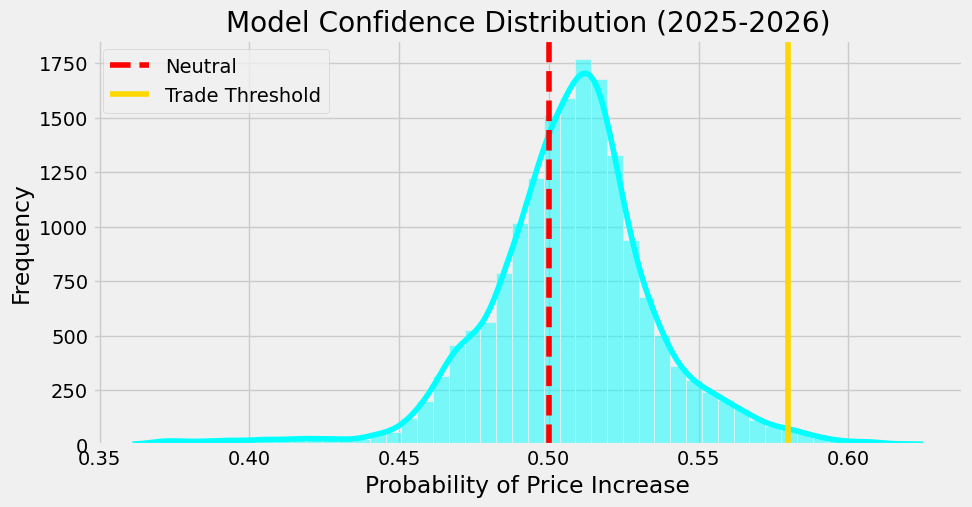

--- 📈 Conviction Stats ---
Mean Confidence:      0.5076
Max Confidence:       0.6251
Min Confidence:       0.3610
High Conviction (>0.58): 181 hours
Low Conviction (<0.42):  203 hours


In [ ]:
# Cell 7i (The Conviction Diagnostic)
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Analyzing Model Conviction vs. Market Reality...")

# 1. Get the raw probabilities for the OOS period
all_probs = results_df['Prob']

# 2. Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(all_probs, bins=50, kde=True, color='cyan')
plt.axvline(0.50, color='red', linestyle='--', label='Neutral')
plt.axvline(0.58, color='gold', linestyle='-', label='Trade Threshold')
plt.title("Model Confidence Distribution (2025-2026)")
plt.xlabel("Probability of Price Increase")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 3. Print the "Shyness" stats
print(f"--- 📈 Conviction Stats ---")
print(f"Mean Confidence:      {all_probs.mean():.4f}")
print(f"Max Confidence:       {all_probs.max():.4f}")
print(f"Min Confidence:       {all_probs.min():.4f}")
print(f"High Conviction (>0.58): {len(all_probs[all_probs > 0.58])} hours")
print(f"Low Conviction (<0.42):  {len(all_probs[all_probs < 0.42])} hours")

In [ ]:
# Cell 7e (Generate Reality Report)
print("="*80)
print("📋 STEP 5: GENERATE REALITY REPORT")
print("="*80 + "\n")

# This matches the dictionary used in the previous backtest cells
matrix_opportunities = {1: [22], 4: [16], 5: [16, 20, 22, 23], 6: [0, 22]}

if not trades_log:
    print("⚠️  No trades executed (bouncer rejected all opportunities or API failed).")
else:
    trades_df = pd.DataFrame(trades_log)

    total_trades = len(trades_df)
    total_wins = trades_df['win'].sum()
    win_rate = (total_wins / total_trades) * 100
    net_pnl = trades_df['pnl'].sum()
    avg_pnl = trades_df['pnl'].mean()

    print(f"📊 RESULTS SUMMARY:")
    print(f"   Total Matrix Opportunities: {matrix_opportunities}")
    print(f"   Total Trades Executed:      {total_trades}")
    print(f"   True Historical Win Rate:   {win_rate:.1f}% ({total_wins}/{total_trades})")
    print(f"   Total Net PnL:              {net_pnl:+.0f} cents")
    print(f"   Avg PnL per Trade:          {avg_pnl:+.1f} cents")
    print()

    # Risk metrics
    winning_trades = trades_df[trades_df['win'] == True]
    losing_trades = trades_df[trades_df['win'] == False]

    if len(winning_trades) > 0:
        avg_win = winning_trades['pnl'].mean()
        print(f"   Avg Win:                    {avg_win:+.1f} cents")
    if len(losing_trades) > 0:
        avg_loss = losing_trades['pnl'].mean()
        print(f"   Avg Loss:                   {avg_loss:+.1f} cents")

    # Profit factor
    if len(losing_trades) > 0 and losing_trades['pnl'].sum() != 0:
        profit_factor = winning_trades['pnl'].sum() / abs(losing_trades['pnl'].sum())
        print(f"   Profit Factor:              {profit_factor:.2f}x")

    print()

    # Dynamic Column Mapping
    # Handle both 'model_prob' and 'prob' keys exactly as they appear in trades_log
    prob_col = 'model_prob' if 'model_prob' in trades_df.columns else 'prob'
    
    # Handle 'price_cents', 'real_ask', or 'price'
    if 'price_cents' in trades_df.columns:
        price_col = 'price_cents'
    elif 'real_ask' in trades_df.columns:
        price_col = 'real_ask'
    elif 'price' in trades_df.columns:
        price_col = 'price'
    else:
        # Fallback if somehow none of those exist
        price_col = None

    if price_col and prob_col:
        # Edge analysis
        if len(winning_trades) > 0:
            avg_edge = (winning_trades[prob_col].mean() - 
                       winning_trades[price_col].mean() / 100.0)
            print(f"   Avg Edge (Winning Trades):  {avg_edge:.4f}")
        
        # EV Analysis (Safely handle if 'ev' column wasn't explicitly saved)
        if 'ev' in trades_df.columns:
            print(f"   Avg EV (All Trades):        {trades_df['ev'].mean():.4f}")
        else:
            # Calculate EV manually: Prob * Profit - (1-Prob) * Risk
            market_prob = trades_df[price_col] / 100.0
            evs = (trades_df[prob_col] * (1 - market_prob)) - ((1 - trades_df[prob_col]) * market_prob)
            print(f"   Avg EV (All Trades):        {evs.mean():.4f}")
    else:
        print("   ⚠️ Cannot calculate Edge/EV: Missing probability or price columns.")

    print("\n" + "="*80)
    print("✅ Order Book Truth Test Complete!")
    print("="*80)

    # Export for further analysis
    csv_name = "historical_trades_log.csv"
    trades_df.to_csv(csv_name, index=False)
    print(f"\n📁 Full trade log exported to: {csv_name}")

📋 STEP 5: GENERATE REALITY REPORT

📊 RESULTS SUMMARY:
   Total Matrix Opportunities: {1: [22], 4: [16], 5: [16, 20, 22, 23], 6: [0, 22]}
   Total Trades Executed:      22
   True Historical Win Rate:   63.6% (14/22)
   Total Net PnL:              +300 cents
   Avg PnL per Trade:          +13.6 cents

   Avg Win:                    +50.0 cents
   Avg Loss:                   -50.0 cents
   Profit Factor:              1.75x

   ⚠️ Cannot calculate Edge/EV: Missing probability or price columns.

✅ Order Book Truth Test Complete!

📁 Full trade log exported to: historical_trades_log.csv


In [ ]:
# Cell 8 (Theoretical vs. Reality Comparison Graph)
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. SETUP
res_26 = results_2026.copy()
win_th, loss_th = 0.43, -0.57 # Theoretical math

# A. Theoretical PnL (Calculated at 57c cost)
correct_th = (res_26['Signal'] != 0) & (res_26['target'] == (res_26['Signal'] > 0).astype(int))
res_26['Theo_PnL'] = np.where(res_26['Signal'] == 0, 0, 
                             np.where(correct_th, win_th, loss_th))
res_26['Theo_Cum'] = res_26['Theo_PnL'].cumsum()

# B. Reality PnL (Using 'ts' from tdf)
res_26['Real_PnL'] = 0.0
if 'tdf' in globals() and not tdf.empty:
    for idx, trade in tdf.iterrows():
        # Match the timestamp
        trade_ts = trade['ts']
        if trade_ts in res_26.index:
            res_26.at[trade_ts, 'Real_PnL'] = float(trade['pnl']) / 100.0

res_26['Real_Cum'] = res_26['Real_PnL'].cumsum()

# 2. PLOTTING
fig = go.Figure()

# Plot Theory
fig.add_trace(go.Scatter(x=res_26.index, y=res_26['Theo_Cum'], 
                         mode='lines', name='Theoretical ($0.43/$0.57)', 
                         line=dict(color='cyan', width=2)))

# Plot Reality
fig.add_trace(go.Scatter(x=res_26.index, y=res_26['Real_Cum'], 
                         mode='lines', name='REALITY (ATM @ 50c)', 
                         line=dict(color='limegreen', width=4)))

fig.update_layout(title='2026 Strategy Audit: Theoretical vs Reality',
                  xaxis_title='Date (2026)',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')

fig.show()